# Introduction to Data Science Lab (j9)
#### Asad Ali, 03-134202-013

#### **Objective(s):**
Upon completion of this lab session, learners will be able to:
- Analyze and Preprocess Textual Data.
- Extract Relevant Features from the Text.
- Train, and Evaluate ML Model on the Text data.
- Make Predictions of the Trained Model on Unseen User Input.


#### **Tasks:**
In this lab, your task is to implement a Machine Learning Classifier on the textual data. For that purpose, first you are required to read, understand, and implement techniques to pre-process textual dataset. Consider email spam/ham classification dataset in this case. It is a binary classification dataset in which the goal of model is to identify either the input email is spam or not spam.

Input: Emails 
Output: Not Spam = 0, Spam = 1


## Section 1: Preprocessing

In [50]:
# import Libraries
import nltk
import random
import string
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/vscode/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/vscode/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [51]:
data = pd.read_csv("./spam.csv", encoding='latin-1')
print(data.head(5))


     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [52]:
data = data[['v1', 'v2']]
data = data.rename(columns={'v1': 'label', 'v2': 'text'})
data['label'] = data['label'].map({'ham':0, 'spam':1})

In [53]:
print(data.isnull().sum())

label    0
text     0
dtype: int64


In [54]:
# Preprocessing the text
def clean(text):
    text = text.lower()
    # remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove whitespace
    text = text.strip()
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
data['clean'] = data['text'].apply(clean)
print(data.head(2))


   label                                               text  \
0      0  Go until jurong point, crazy.. Available only ...   
1      0                      Ok lar... Joking wif u oni...   

                                               clean  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  


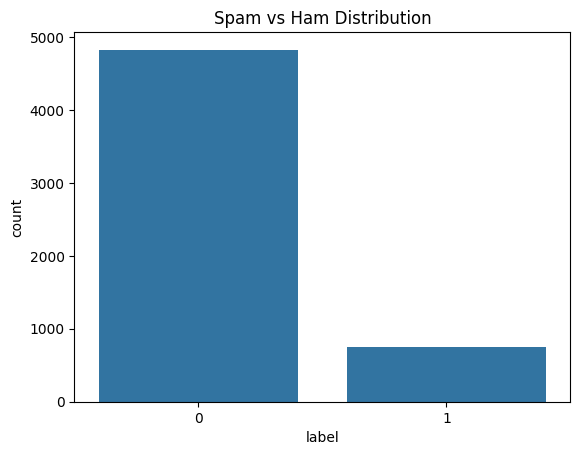

In [55]:
# 5. Visualize the data
# Spam vs Ham distribution
import seaborn as sns
sns.countplot(x='label', data=data)
plt.title('Spam vs Ham Distribution')
plt.show()


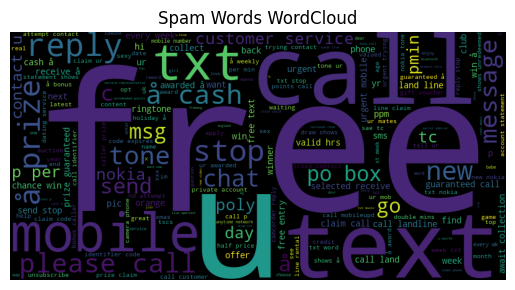

In [56]:
from wordcloud import WordCloud
spam_words = ' '.join(list(data[data['label'] == 1]['clean']))
ham_words = ' '.join(list(data[data['label'] == 0]['clean']))
wc = WordCloud(width=800, height=400).generate(spam_words)
plt.imshow(wc)
plt.axis('off')
plt.title('Spam Words WordCloud')
plt.show()

In [57]:
# 6. Feature Extraction using TF-IDF 
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(data['clean']).toarray()
y = data['label']


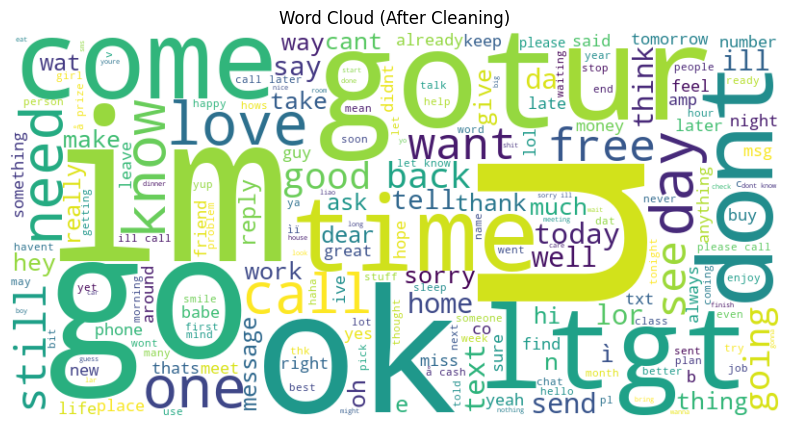

In [58]:
# 6. Visualize after preprocessing
# Wordcloud after cleaning
text_combined_clean = ' '.join(data['clean'])
wc_clean = WordCloud(width=800, height=400, background_color='white').generate(text_combined_clean)
plt.figure(figsize=(10,5))
plt.imshow(wc_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud (After Cleaning)')
plt.show()

In [59]:
# 7. Feature Extraction using TF-IDF
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(data['clean']).toarray()
y = data['label']

In [60]:
# 8. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [61]:
# 9. Train the classifier
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [62]:
# 9. Evaluate the model
y_pred = model.predict(X_test)



Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.65      0.77       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115



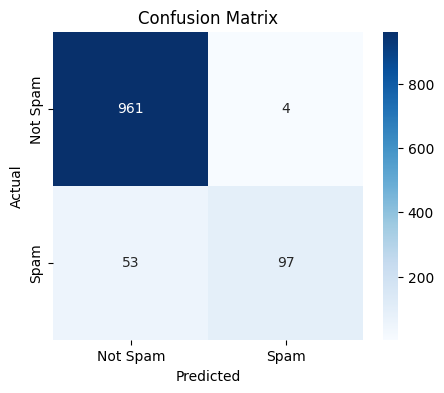

In [63]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [64]:
# 11. Save the model using pickle
import pickle
with open('best_spam_classifier.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("✅ Model and Vectorizer saved successfully with pickle!")

✅ Model and Vectorizer saved successfully with pickle!


In [ ]:
# 12. Predict on unseen user input
def predict_email(email_text):
    # Load the model and vectorizer
    with open('best_spam_classifier.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        loaded_vectorizer = pickle.load(f)
        
    # Preprocess input
    cleaned_input = clean(email_text)
    transformed_input = loaded_vectorizer.transform([cleaned_input]).toarray()
    
    # Predict
    prediction = loaded_model.predict(transformed_input)
    return "Spam" if prediction[0] == 1 else "Not Spam"

# Example usage
user_input = input("\nEnter an email text to classify: ")
if len(user_input.split()) < 4:
    user_input = user_input + " please check offer prize"  
result = predict_email(user_input)
print(f"The email is classified as: {result}")


The email is classified as: Spam
